In [1]:
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
import datetime
import warnings # Silence the warnings from SHARPpy
warnings.filterwarnings("ignore")
from scipy import interpolate
from scipy.ndimage import gaussian_filter
import scipy
import scipy.stats
import math
import cmweather
import matplotlib.patches as mpatches
import glob
import os
from metpy.units import units
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 20
from matplotlib.ticker import FormatStrFormatter
import pingouin as pg
import shapely
import shapely.plotting
import shapely.wkt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr, kendalltau

In [2]:
d = {}
d_full = {}
d_full2 = {}
d3 = {}

path = '/data/keeling/a/melinda3/gpm/data_dir/'
path2 = '/data/keeling/a/melinda3/meso/pres_perts_dir/'


lower_shear = [6, 8, 10]
upper_shear = [31, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_dss".format(li, ui)] = file_in

        hash2 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
        file_in2 = pd.read_csv(path2+hash2)
        file_in2 = file_in2.replace(-9999, np.nan)
        d_full2["area{0}_{1}_dss".format(li, ui)] = file_in2


d = d_full
d3 = d_full2

In [3]:
uca_con = np.zeros(len(d))
ota_con = np.zeros(len(d))
bshear_con = np.zeros(len(d))
hodol_con = np.zeros(len(d))
hodor_con = np.zeros(len(d))
cv_con = np.zeros(len(d))
n2_con = np.zeros(len(d))
srh_con = np.zeros(len(d))
otd_con = np.zeros(len(d))
upper_area_con = np.zeros(len(d))
upper_velo_con = np.zeros(len(d))
lower_area_con = np.zeros(len(d))
lower_velo_con = np.zeros(len(d))
el_velo_con = np.zeros(len(d))
lower_vort = np.zeros(len(d))
mid_vort = np.zeros(len(d))
upper_vort = np.zeros(len(d))


n = 0
for key in d:
    print(key)
    data = d[key]
    data2 = d3[key]
    data = data[data.time > data.time_split.iloc[0]]
    data2 = data2[data2.time > data.time_split.iloc[0]]
    uca_bshear = data['bshear06'].iloc[0]
    n2 = data['n2'].iloc[0]
    srh = data['srh03'].iloc[0]

    core_data = data[(data.z >= 4) & (data.z < 8)]
    ot_data = data[(data.z > 13.3) & (data.z < 13.4)]
    lower_data = data[(data.z >= 2.5) & (data.z < 4)] 
    upper_data = data[(data.z >= 8) & (data.z < 12.5)]
    otd_data = data[(data.z > 13.375)]
    otd_grouped = otd_data.groupby("time", dropna = True)
    grouped_core_data = core_data.groupby("time", dropna = True)
    grouped_upper_data = upper_data.groupby('time', dropna =True)
    grouped_lower_data = lower_data.groupby('time', dropna = True)
    grouped_ot_data = ot_data.groupby("time", dropna=True)

    core_data2 = data2[(data2.hght >= 4) & (data2.hght < 8)]
    ot_data2 = data2[(data2.hght > 13.3) & (data2.hght < 13.4)]
    lower_data2 = data2[(data2.hght >= 2.5) & (data2.hght < 4)] 
    upper_data2 = data2[(data2.hght >= 8) & (data2.hght < 12.5)]
    otd_data2 = data2[(data2.hght > 13.375)]
    otd_grouped2 = otd_data2.groupby("time", dropna = True)
    grouped_core_data2 = core_data2.groupby("time", dropna = True)
    grouped_upper_data2 = upper_data2.groupby('time', dropna =True)
    grouped_lower_data2 = lower_data2.groupby('time', dropna = True)
    grouped_ot_data2 = ot_data2.groupby("time", dropna=True)

    uca_area = grouped_core_data.mean('z').max()['polygon_med_area']
    core_velo = grouped_core_data.mean('z').max()['max_velo']
    ota_area = grouped_ot_data.mean('z').max()['polygon_med_area']
    lower_area = grouped_lower_data.mean('z').max()['polygon_med_area']
    upper_area = grouped_upper_data.mean('z').max()['polygon_med_area']
    upper_velo = grouped_upper_data.mean('z').max()['max_velo'] 
    lower_velo = grouped_lower_data.mean('z').max()['max_velo']
    otd = otd_grouped.max('z').max()['z']
    otd = otd - 13.375
    el_velo = grouped_ot_data.mean('z').max()['max_velo']

    lv = grouped_lower_data2.mean('hght').max()['zvavg_over_polygon']
    mv = grouped_core_data2.mean('hght').max()['zvavg_over_polygon']
    uv = grouped_upper_data2.mean('hght').max()['zvavg_over_polygon']

    if "6" in key:
        hodo_rad_key = np.int64(key[4])
        hodo_len_key = np.int64(key[6:8])
    elif "8" in key:
        hodo_rad_key = np.int64(key[4])
        hodo_len_key = np.int64(key[6:8])
    elif "4" in key:
        hodo_rad_key = np.int64(key[4])
        hodo_len_key = np.int64(key[6:8])
    else:
        hodo_rad_key = np.int64(key[4:6])
        hodo_len_key = np.int64(key[7:9])

    uca_con[n] = uca_area * .5 * .5
    ota_con[n] = ota_area * .5 * .5
    bshear_con[n] = uca_bshear
    cv_con[n] = core_velo
    hodor_con[n] = hodo_rad_key
    hodol_con[n] = hodo_len_key
    n2_con[n] = n2
    srh_con[n] = srh
    upper_area_con[n] = upper_area * .5 * .5
    lower_area_con[n] = lower_area * .5 * .5
    el_velo_con[n] = el_velo
    otd_con[n] = otd
    lower_velo_con[n] = lower_velo
    upper_velo_con[n] = upper_velo
    lower_vort[n] = lv
    mid_vort[n] = mv
    upper_vort[n] = uv

    n+=1

dict = {'uca':uca_con, 'ota':ota_con, 'bshear':bshear_con,\
        'core_velo':cv_con, 'hodo_r':hodor_con, 'hodo_l':hodol_con,\
        'lca':lower_area_con, 'upca':upper_area_con, 'n2':n2_con,\
        'srh':srh_con, 'lvel':lower_velo_con, 'upvel':upper_velo_con,\
        'el_vel':el_velo_con, 'otd':otd_con, 'lower_vort':lower_vort, 'mid_vort':mid_vort,\
            'upper_vort':upper_vort}

data_dict = pd.DataFrame(dict)

area6_31_dss
area6_33_dss
area6_35_dss
area8_31_dss
area8_33_dss
area8_35_dss
area10_31_dss
area10_33_dss
area10_35_dss


In [4]:
ota_pred_cols = ['uca', 'hodo_r', 'hodo_l', 'n2']
X_ota = data_dict[ota_pred_cols]
Y_ota = data_dict['upca']
ota_vars = data_dict[['ota', 'upca', 'uca', 'lca', 'hodo_r', 'hodo_l', 'n2']]

otd_pred_cols = ['core_velo', 'hodo_r', 'hodo_l', 'n2']
X_otd = data_dict[otd_pred_cols]
Y_otd = data_dict['otd']
otd_vars = data_dict[['otd', 'upvel', 'core_velo', 'lvel', 'hodo_r', 'hodo_l', 'n2']]

uluca_vars = data_dict[['upca', 'uca', 'lca', 'hodo_r', 'hodo_l', 'n2']]
ulcv_vars = data_dict[['upvel', 'core_velo', 'lvel', 'hodo_r', 'hodo_l', 'srh',\
                       'lower_vort', 'mid_vort', 'upper_vort']]

In [5]:
#Get Spearman rank correlations to understand if the data are monotonic or not

ota_corrs, ota_pvals = spearmanr(ota_vars)
otd_corrs, otd_pvals = spearmanr(otd_vars)

uluca_corrs, uluca_pvals = spearmanr(uluca_vars)
ulcv_corrs, ulcv_pvals = spearmanr(ulcv_vars)
ulcv_kend_stats = pg.pairwise_corr(ulcv_vars, method = 'kendall')

In [9]:
kend_dict = {'upvel_r':ulcv_kend_stats[ulcv_kend_stats.X == 'upvel']['r'], 'upvel_p':ulcv_kend_stats[ulcv_kend_stats.X == 'upvel']['p-unc'],\
    'core_vel_r':ulcv_kend_stats[ulcv_kend_stats.X == 'core_velo']['r'] , 'core_vel_p':ulcv_kend_stats[ulcv_kend_stats.X == 'core_velo']['p-unc'],\
    'lvel_r':ulcv_kend_stats[ulcv_kend_stats.X == 'lvel']['r'] ,'lvel_p':ulcv_kend_stats[ulcv_kend_stats.X == 'lvel']['p-unc'],\
    'hodor_r':ulcv_kend_stats[ulcv_kend_stats.X == 'hodo_r']['r'] ,'hodor_p':ulcv_kend_stats[ulcv_kend_stats.X == 'hodo_r']['p-unc'],\
    'hodol_r':ulcv_kend_stats[ulcv_kend_stats.X == 'hodo_l']['r'] ,'hodol_p':ulcv_kend_stats[ulcv_kend_stats.X == 'hodo_l']['p-unc'],\
    'srh_r':ulcv_kend_stats[ulcv_kend_stats.X == 'srh']['r'] ,'srh_p':ulcv_kend_stats[ulcv_kend_stats.X == 'srh']['p-unc'],\
    'lower_vort_r':ulcv_kend_stats[ulcv_kend_stats.X == 'lower_vort']['r'] ,'lower_vort_p':ulcv_kend_stats[ulcv_kend_stats.X == 'lower_vort']['p-unc'],\
    'mid_vort_r':ulcv_kend_stats[ulcv_kend_stats.X == 'mid_vort']['r'] ,'mid_vort_p':ulcv_kend_stats[ulcv_kend_stats.X == 'mid_vort']['p-unc'],\
    'upper_vort_r':ulcv_kend_stats[ulcv_kend_stats.X == 'upper_vort']['r'] ,'upper_vort_p':ulcv_kend_stats[ulcv_kend_stats.X == 'upper_vort']['p-unc']}
kend_df = pd.DataFrame(kend_dict)

In [10]:
r_df = kend_df[['upvel_r', 'core_vel_r', 'lvel_r', 'hodor_r', 'hodol_r', 'srh_r', 'lower_vort_r', 'mid_vort_r', 'upper_vort_r']]
p_df = kend_df[['upvel_p', 'core_vel_p', 'lvel_p', 'hodor_p', 'hodol_p', 'srh_p', 'lower_vort_p', 'mid_vort_p', 'upper_vort_p']]

In [11]:
r_df

,upvel_r,core_vel_r,lvel_r,hodor_r,hodol_r,srh_r,lower_vort_r,mid_vort_r,upper_vort_r
0,0.111111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.111111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.481125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.224525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,-0.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,-0.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.055556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,0.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,0.288675,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
upvel_r.shape

(9,)

In [33]:
upvel_r = r_df['upvel_r'][0:8].values.reshape(-1,1)
upvel_r = np.insert(upvel_r, 0, np.nan).reshape(-1,1)
core_vel_r = r_df['core_vel_r'][6:15].values.reshape(-1,1)
lvel_r = r_df['lvel_r'][12:21].values.reshape(-1,1)
hodor_r = r_df['hodor_r'][17:26].values.reshape(-1,1)
hodol_r = r_df['hodol_r'][21:30].values.reshape(-1,1)
srh_r = r_df['srh_r'][24:33].values.reshape(-1,1)
lower_vort_r = r_df['lower_vort_r'][26:35].values.reshape(-1,1)
mid_vort_r = r_df['mid_vort_r'][27:36].values.reshape(-1,1)
upper_vort_r = r_df['upper_vort_r'][24:33].values.reshape(-1,1)

r_matrix = np.hstack([upvel_r, core_vel_r, lvel_r, hodor_r, hodol_r, srh_r, lower_vort_r, mid_vort_r, upper_vort_r])

upvel_p = p_df['upvel_p'][0:8].values.reshape(-1,1)
upvel_p = np.insert(upvel_p, 0, np.nan).reshape(-1,1)
core_velo_p = p_df['core_vel_p'][6:15].values.reshape(-1,1)
lvel_p = p_df['lvel_p'][12:21].values.reshape(-1,1)
hodor_p = p_df['hodor_p'][17:26].values.reshape(-1,1)
hodol_p = p_df['hodol_p'][21:30].values.reshape(-1,1)
srh_p = p_df['srh_p'][24:33].values.reshape(-1,1)
lower_vort_p = p_df['lower_vort_p'][26:35].values.reshape(-1,1)
mid_vort_p = p_df['mid_vort_p'][27:36].values.reshape(-1,1)
upper_vort_p = p_df['upper_vort_p'][24:33].values.reshape(-1,1)

p_matrix = np.hstack([upvel_p, core_velo_p, lvel_p, hodor_p, hodol_p, srh_p, lower_vort_p, mid_vort_p, upper_vort_p])

In [34]:
#Only apply bold to the correlations that are statistically signficant
#Modeled off of https://www.geeksforgeeks.org/step-by-step-guide-to-annotating-diagonal-elements-in-seaborn-heatmaps/

def annotate_diagonal(data, mask, ax, corr_data, diag_mask):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if diag_mask[i,j] == False:
                if mask[i, j]:
                    if corr_data[i,j] <= -0.2:
                        ax.text(j + 0.5, i + 0.5, f'{corr_data[i, j]:.1f}', 
                                ha='center', va='center', fontweight = 'bold', color = 'white')
                    elif corr_data[i,j] >= 0.6:
                        ax.text(j + 0.5, i + 0.5, f'{corr_data[i, j]:.1f}', 
                                ha='center', va='center', fontweight = 'bold', color = 'white')
                    else:
                        ax.text(j + 0.5, i + 0.5, f'{corr_data[i, j]:.1f}', 
                                ha='center', va='center', fontweight = 'bold', color = 'white')
                else:
                    ax.text(j + 0.5, i + 0.5, f'{corr_data[i, j]:.1f}', 
                                ha='center', va='center')
            else:
                continue

In [35]:
otamask = np.zeros_like(ota_corrs, dtype=bool)
otamask[np.triu_indices_from(otamask)] = True

otdmask = np.zeros_like(otd_corrs, dtype=bool)
otdmask[np.triu_indices_from(otdmask)] = True

ulucamask = np.zeros_like(uluca_corrs, dtype=bool)
ulucamask[np.triu_indices_from(ulucamask)] = True

ulcvmask = np.zeros_like(ulcv_corrs, dtype=bool)
ulcvmask[np.triu_indices_from(ulcvmask)] = True

ulcv_kend_mask = np.zeros_like(r_matrix, dtype = bool)
ulcv_kend_mask[np.triu_indices_from(ulcv_kend_mask)] = True

In [36]:
ota_mask = ota_pvals < 0.05
otd_mask = otd_pvals < 0.05
uluca_mask = uluca_pvals < 0.05
ulcv_mask = ulcv_pvals < 0.05

ulcv_p_mask = p_matrix < 0.05

ota_labels = ['OTA', 'ULUCA', 'MLUCA', 'LLUCA', '0-2HR', '2-6HL', '$N^{\mathrm{2}}$']
otd_labels = ['OTD', 'ULUC W', 'MLUC W', 'LLUC W', '0-2HR', '2-6HL', '$N^{2}$']
uluca_labels = ['ULUCA', 'MLUCA', 'LLUCA', '0-2HR', '2-6HL','$N^{2}$' ]
ulcv_labels = ['ULUC W', 'MLUC W', 'LLUC W', '0-2HR', '2-6HL', '0-3SRH',\
               'LLUC ${\mathrm{\zeta}}$', 'MLUC ${\mathrm{\zeta}}$', 'ULUC ${\mathrm{\zeta}}$'] 

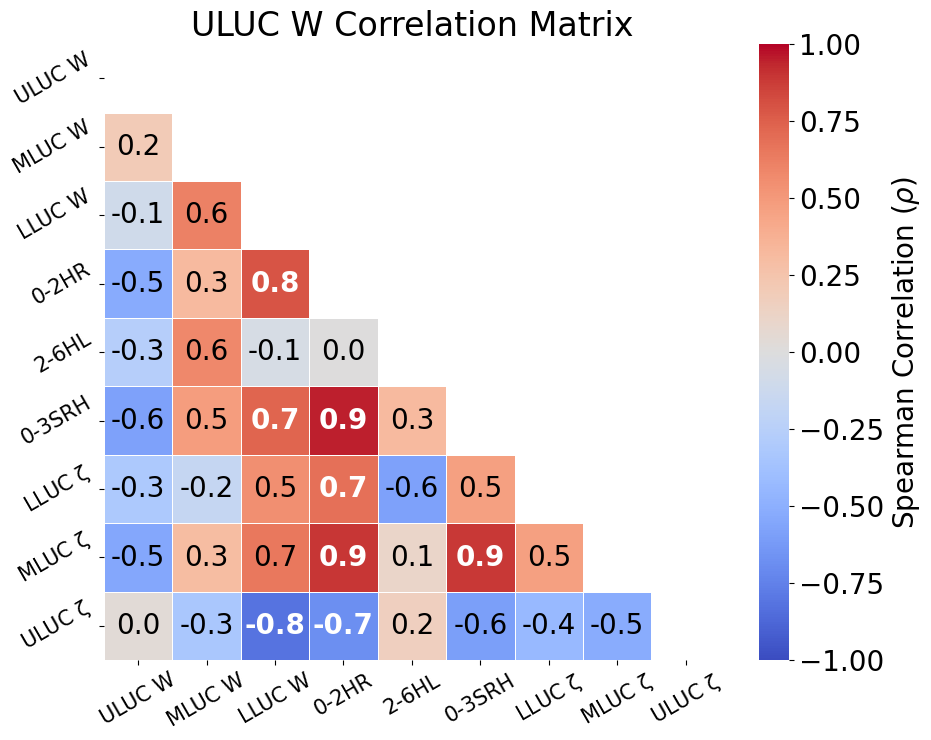

In [37]:
fig, (ax2) = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 8))
cbar_label = 'Spearman Correlation ($\\rho$)'
p2 = sns.heatmap(ulcv_corrs, annot = False, linewidth= 0.5, \
                vmin = -1, vmax = 1 ,ax = ax2, cmap = 'coolwarm', cbar=True, square=True, mask = ulcvmask,\
                    cbar_kws={'label':cbar_label})
ax2.set_title('ULUC W Correlation Matrix')
ax2.set_xticklabels(ulcv_labels, fontsize = 15, rotation = 30)
ax2.set_yticklabels(ulcv_labels, fontsize = 15, rotation = 30)
annotate_diagonal(ulcv_pvals, ulcv_mask, ax2, ulcv_corrs, ulcvmask)

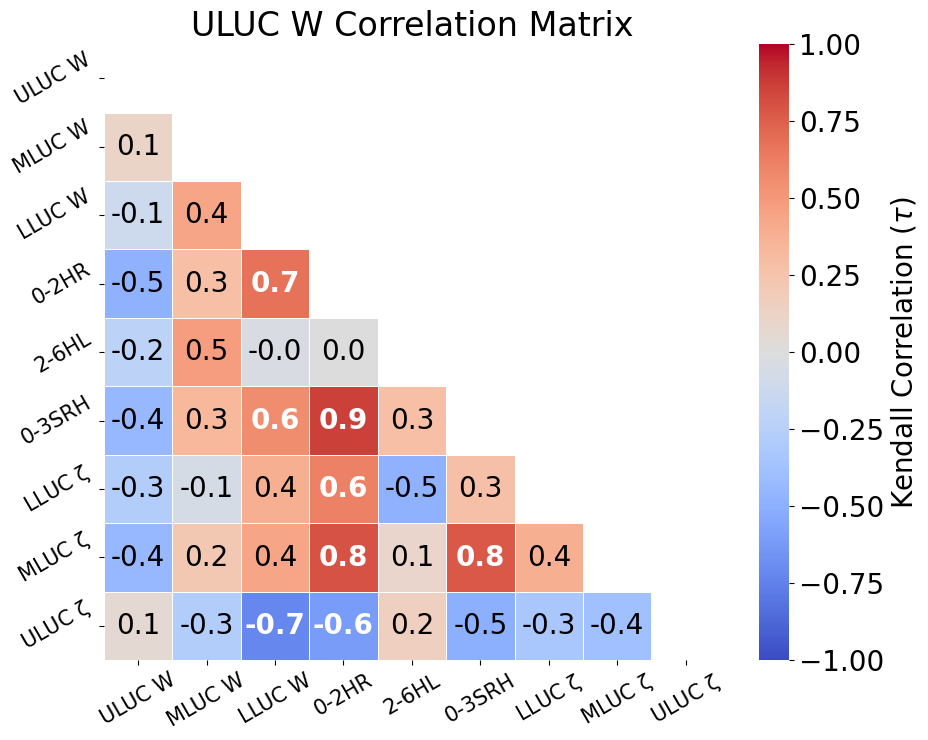

In [38]:
fig, (ax2) = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 8))
cbar_label = 'Kendall Correlation ($\\tau$)'
p2 = sns.heatmap(r_matrix, annot = False, linewidth= 0.5, \
                vmin = -1, vmax = 1 ,ax = ax2, cmap = 'coolwarm', cbar=True, square=True, mask = ulcv_kend_mask,\
                    cbar_kws={'label':cbar_label})
ax2.set_title('ULUC W Correlation Matrix')
ax2.set_xticklabels(ulcv_labels, fontsize = 15, rotation = 30)
ax2.set_yticklabels(ulcv_labels, fontsize = 15, rotation = 30)
annotate_diagonal(p_matrix, ulcv_p_mask, ax2, r_matrix, ulcv_kend_mask)

In [39]:
r_matrix

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [ 0.11111111,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [-0.11111111,  0.44444444,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [-0.48112522,  0.28867513,  0.67357531,         nan,         nan,
                nan,         nan,         nan,         nan],
       [-0.2245251 ,  0.48112522, -0.03207501,  0.        ,         nan,
                nan,         nan,         nan,         nan],
       [-0.44444444,  0.33333333,  0.55555556,  0.8660254 ,  0.28867513,
                nan,         nan,         nan,         nan],
       [-0.27777778, -0.05555556,  0.38888889,  0.60942528, -0.48112522,
         0.27777778,         nan,         nan,         nan],
       [-0.44444444,  0.22222222,  0.44444444,  0.80187537,  0